<a href="https://colab.research.google.com/github/sanghavividhi/Natural-Language-Processing-NLP-/blob/main/10_08_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
data ={
    'Study-Hours':[2,3,1,5,6,4,7,8,2,9,3,6,5,1,7,4,8,2,9,6,3,7,5,2,8,4,9,6,3,7],
    'Attendance':[55,60,50,75,80,70,90,95,58,98,62,85,78,45,92,72,96,52,99,88,65,91,82,48,94,68,97,86,59,89],
    'Assignment_Score':[40,45,35,65,70,60,80,85,42,90,48,75,68,30,88,62,92,38,95,78,50,86,72,32,90,58,94,76,44,84],
    'Internal_Marks':[35,40,30,55,60,50,70,75,38,80,42,65,58,25,72,52,78,32,85,68,45,74,62,28,76,48,82,66,36,71],
    'Result':[0,0,0,1,1,1,1,1,0,1,0,1,1,0,1,1,1,0,1,1,0,1,1,0,1,1,1,1,0,1]
}

df = pd.DataFrame(data)

In [ ]:
print("Student Dataset:")
print(df.head())

Student Dataset:
   Study-Hours  Attendance  Assignment_Score  Internal_Marks  Result
0            2          55                40              35       0
1            3          60                45              40       0
2            1          50                35              30       0
3            5          75                65              55       1
4            6          80                70              60       1


In [ ]:
x= df[['Study-Hours','Attendance','Assignment_Score','Internal_Marks']]
y= df['Result']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler= StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
def create_model(optimizer):
    model = Sequential([Dense(16,activation='relu',input_shape=(4,)),
                        Dense(8,activation='relu'),
                        Dense(1,activation='sigmoid')])
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [ ]:
model_sgd = create_model(
    tf.keras.optimizers.SGD(learning_rate=0.01)
)
history_sgd = model_sgd.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_adam = create_model(
    tf.keras.optimizers.Adam(learning_rate=0.01)
)
history_adam = model_adam.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
sgd_loss,sgd_accuracy = model_sgd.evaluate(x_test,y_test,verbose=0)
adam_loss,adam_accuracy = model_adam.evaluate(x_test,y_test,verbose=0)
print("/n---MODEL COMPARISON---/")
print("SGD Loss:",sgd_loss)
print("SGD Accuracy:",sgd_accuracy)
print("Adam Loss:",adam_loss)
print("Adam Accuracy:",adam_accuracy)

/n---MODEL COMPARISON---/
SGD Loss: 0.2765341103076935
SGD Accuracy: 1.0
Adam Loss: 0.11677360534667969
Adam Accuracy: 1.0


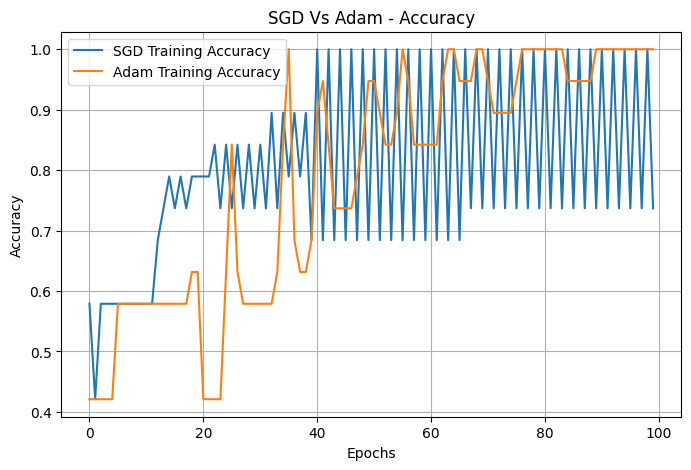

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['accuracy'],label='SGD Training Accuracy')
plt.plot(history_adam.history['accuracy'],label='Adam Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('SGD Vs Adam - Accuracy')
plt.legend()
plt.grid()
plt.show()

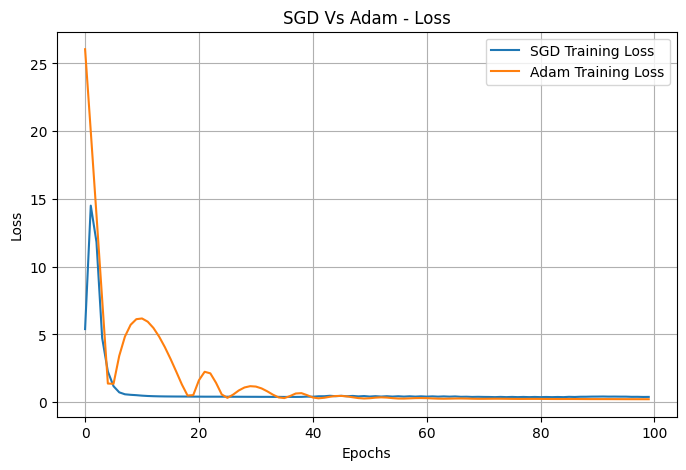

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['loss'],label='SGD Training Loss')
plt.plot(history_adam.history['loss'],label='Adam Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('SGD Vs Adam - Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
new_student = np.array([[7,88,78,72]])

new_student_scaled = scaler.transform(new_student)
prediction = model_adam.predict(new_student_scaled,verbose=0)
probability = prediction[0][0]
print("/n--- NEW STUDENT PREDICTION---/")
print("Probability of Passing:",probability)
if probability >= 0.5:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/n--- NEW STUDENT PREDICTION---/
Probability of Passing: 0.47573897
Prediction: FAIL
